# Proyek Akhir Dicoding: Klasifikasi Gambar CNN — GTSRB Dataset

Dataset: **GTSRB - German Traffic Sign Recognition Benchmark**  
Sumber: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import json

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras import callbacks, models
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")


2026-02-25 02:17:58.478448: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771985878.593969      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771985878.628463      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771985878.896367      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771985878.896401      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771985878.896404      24 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Load dan Eksplorasi Dataset




In [ ]:
DATASET_DIR = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
TRAIN_DIR   = os.path.join(DATASET_DIR, 'Train')
TEST_DIR    = os.path.join(DATASET_DIR, 'Test')
TRAIN_CSV   = os.path.join(DATASET_DIR, 'Train.csv')
TEST_CSV    = os.path.join(DATASET_DIR, 'Test.csv')
META_CSV    = os.path.join(DATASET_DIR, 'Meta.csv')

NUM_CLASSES = 43
IMG_SIZE    = 30   

# Load Train.csv dan Test.csv
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print(f"\nTrain.csv shape : {df_train.shape}")
print(f"Test.csv shape  : {df_test.shape}")




Train.csv shape : (39209, 8)
Test.csv shape  : (12630, 8)


## 3. Preprocessing Dataset



In [ ]:
def load_train_data(train_dir, img_size=30):
    
    images = []
    labels = []

    for class_id in range(NUM_CLASSES):
        class_folder = os.path.join(train_dir, str(class_id))
        if not os.path.exists(class_folder):
            print(f"  [WARNING] Folder kelas {class_id} tidak ditemukan, dilewati.")
            continue

        for img_file in sorted(os.listdir(class_folder)):
            img_path = os.path.join(class_folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(class_id)

    images = np.array(images, dtype=np.float32) / 255.0   
    labels = np.array(labels, dtype=np.int32)
    return images, labels


def load_test_data(test_csv, dataset_dir, img_size=30):
 
    df = pd.read_csv(test_csv)
    images = []
    labels = []

    for _, row in df.iterrows():
        img_path = os.path.join(dataset_dir, row['Path'])
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img)
        labels.append(row['ClassId'])

    images = np.array(images, dtype=np.float32) / 255.0
    labels = np.array(labels, dtype=np.int32)
    return images, labels


print("Memuat data training...")
X_data, y_data = load_train_data(TRAIN_DIR, IMG_SIZE)

print("Memuat data test...")
X_test, y_test_raw = load_test_data(TEST_CSV, DATASET_DIR, IMG_SIZE)

print(f"\nShape X_data   : {X_data.shape}")
print(f"Shape y_data   : {y_data.shape}")
print(f"Shape X_test   : {X_test.shape}")
print(f"Shape y_test   : {y_test_raw.shape}")
print(f"Nilai pixel    : min={X_data.min():.2f}, max={X_data.max():.2f}")
print(f"Jumlah kelas   : {len(np.unique(y_data))}")
print(f"Total gambar   : {len(X_data) + len(X_test):,}")


Memuat data training...
Memuat data test...

Shape X_data   : (39209, 30, 30, 3)
Shape y_data   : (39209,)
Shape X_test   : (12630, 30, 30, 3)
Shape y_test   : (12630,)
Nilai pixel    : min=0.00, max=1.00
Jumlah kelas   : 43
Total gambar   : 51,839


## 4. Visualisasi Dataset

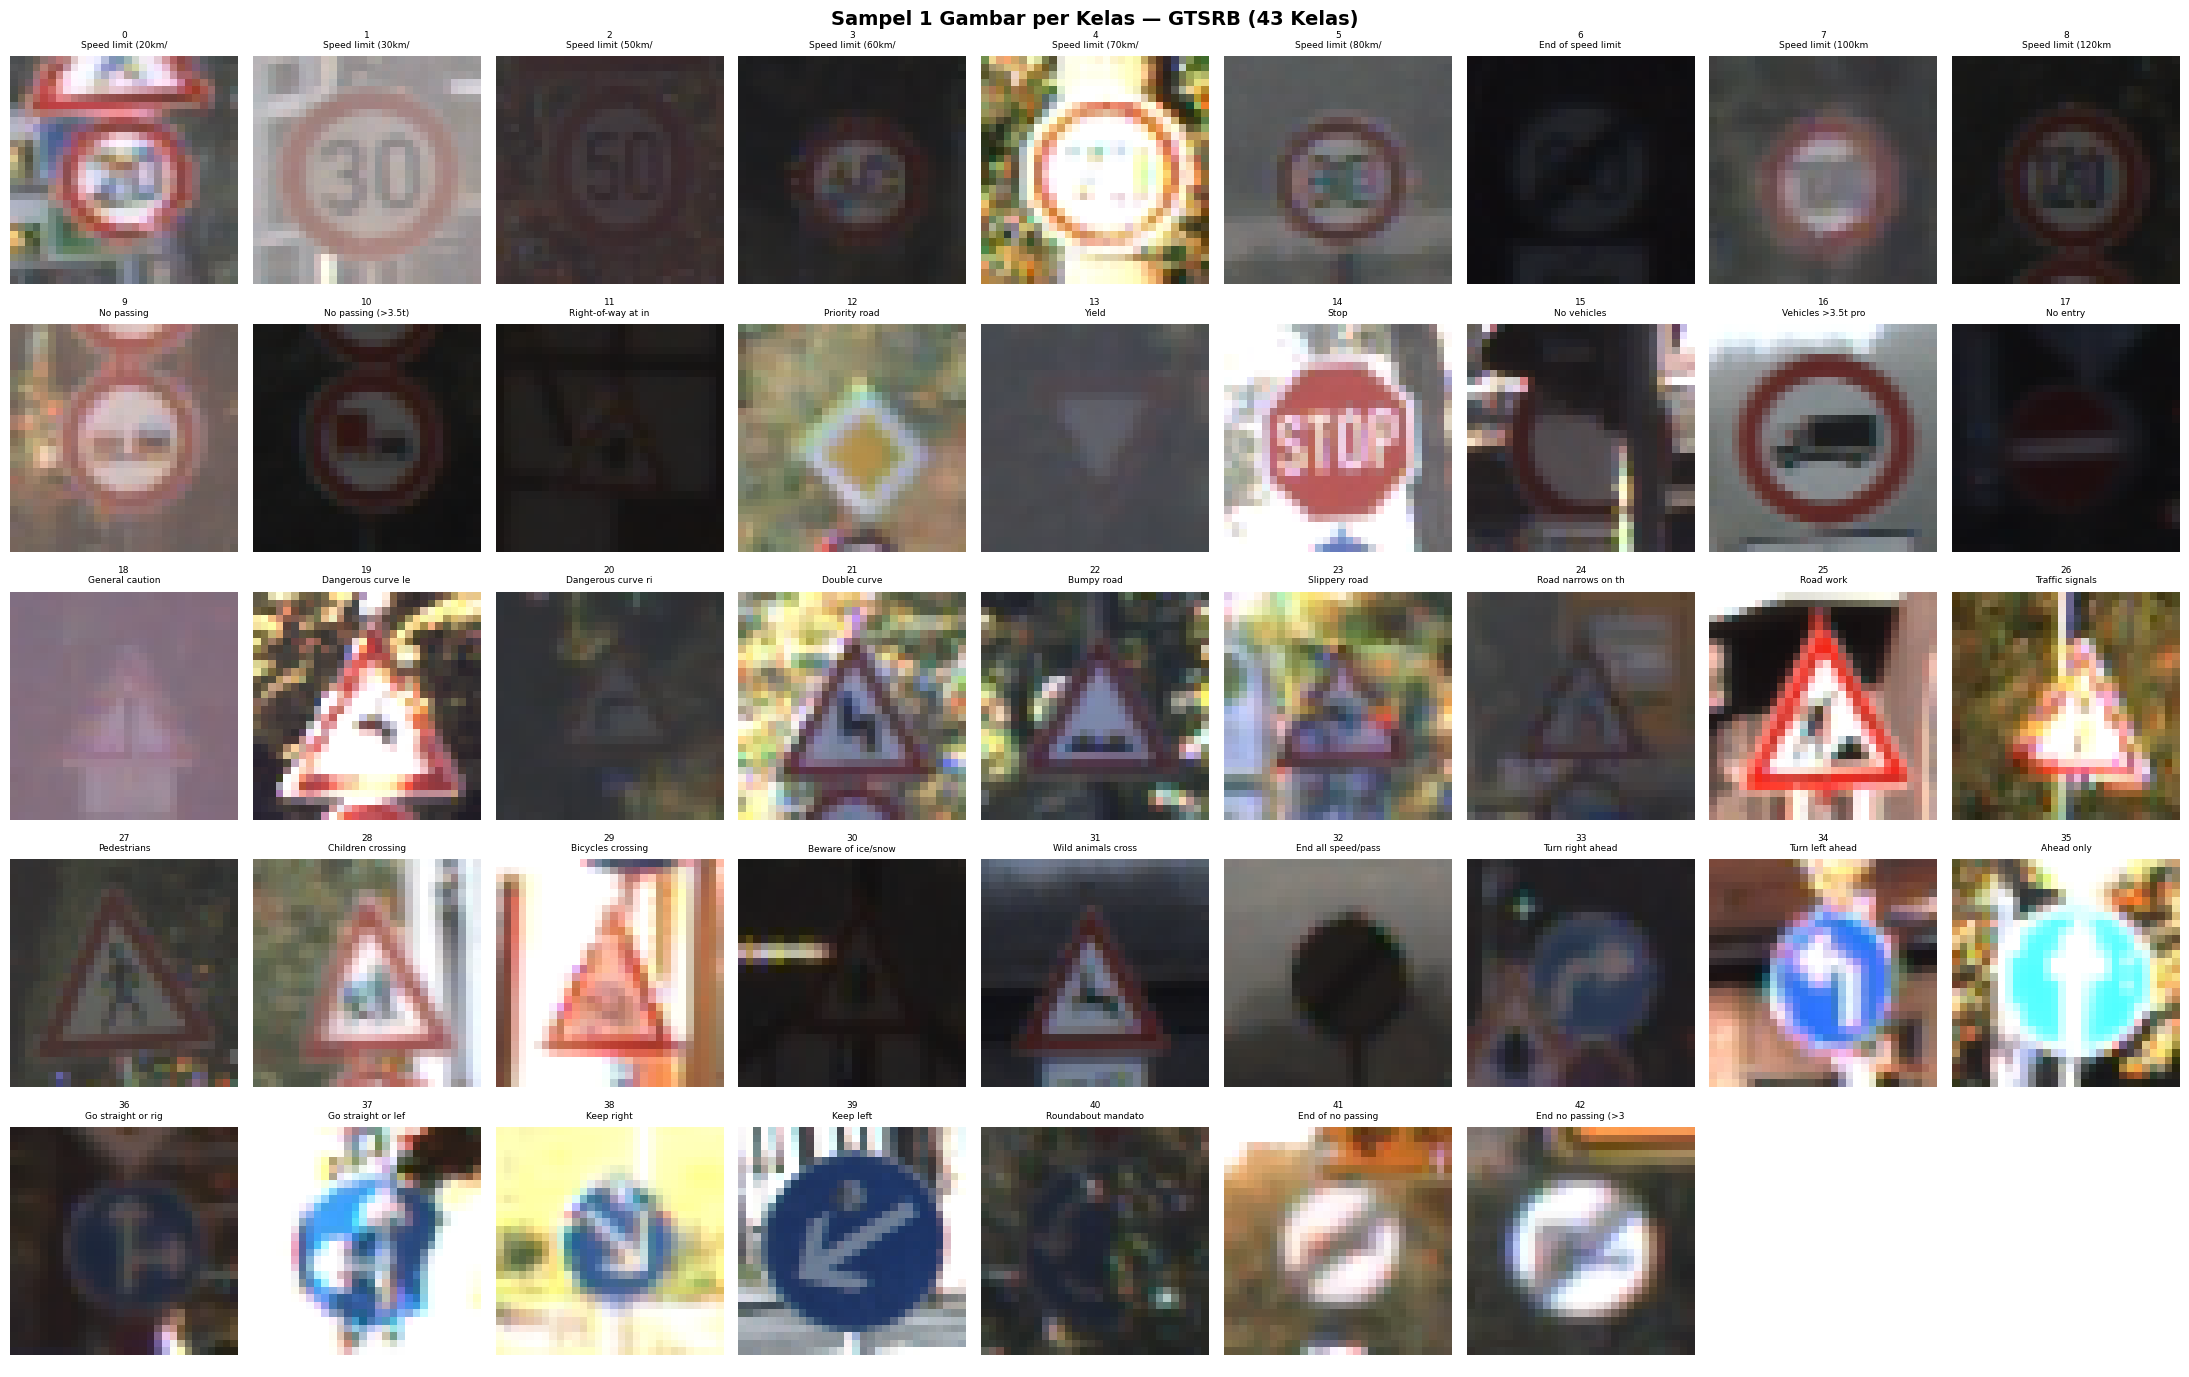

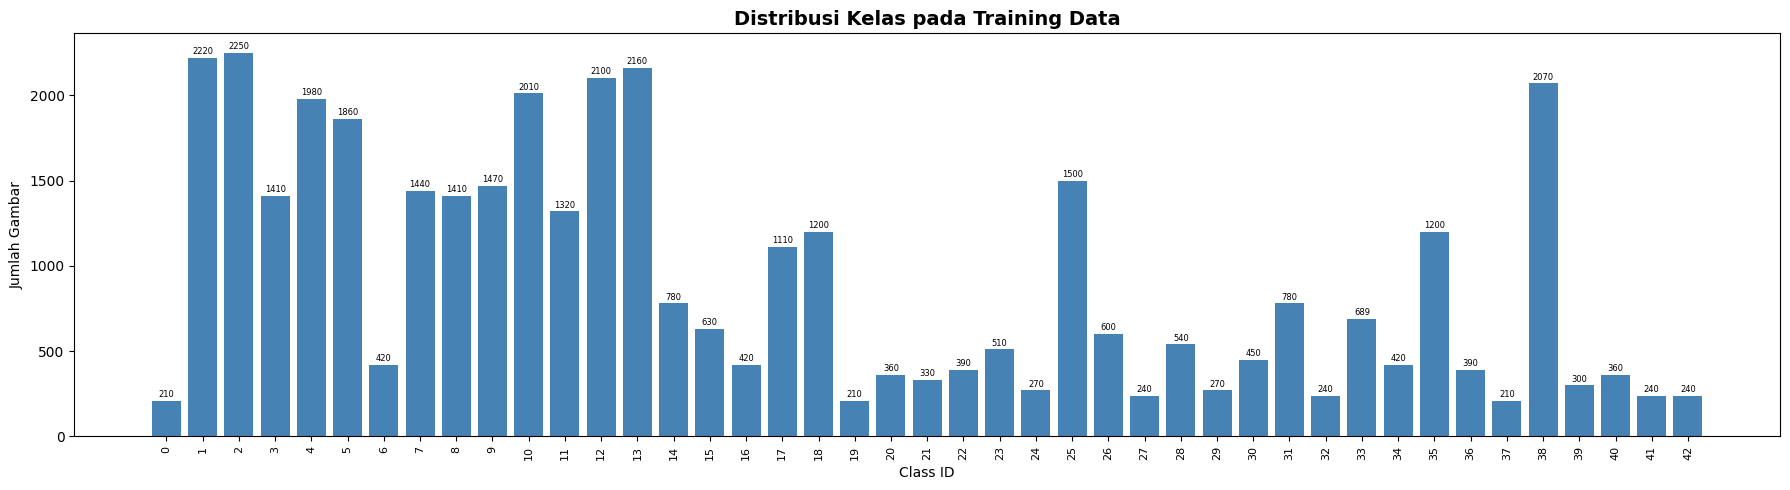


Kelas dengan gambar terbanyak : Speed limit (50km/h) (2,250 gambar)
Kelas dengan gambar tersedikit: Speed limit (20km/h) (210 gambar)
Rata-rata per kelas           : 912 gambar


In [4]:
# Nama kelas GTSRB (43 kelas)
class_names = [
    'Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)',
    'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)',
    'End of speed limit (80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)',
    'No passing', 'No passing (>3.5t)', 'Right-of-way at intersection',
    'Priority road', 'Yield', 'Stop', 'No vehicles',
    'Vehicles >3.5t prohibited', 'No entry', 'General caution',
    'Dangerous curve left', 'Dangerous curve right', 'Double curve',
    'Bumpy road', 'Slippery road', 'Road narrows on the right', 'Road work',
    'Traffic signals', 'Pedestrians', 'Children crossing', 'Bicycles crossing',
    'Beware of ice/snow', 'Wild animals crossing', 'End all speed/passing limits',
    'Turn right ahead', 'Turn left ahead', 'Ahead only', 'Go straight or right',
    'Go straight or left', 'Keep right', 'Keep left',
    'Roundabout mandatory', 'End of no passing', 'End no passing (>3.5t)'
]

# Visualisasi 1 sampel per kelas 
fig, axes = plt.subplots(5, 9, figsize=(22, 14))
for class_id, ax in enumerate(axes.flat):
    if class_id >= NUM_CLASSES:
        ax.axis('off')
        continue
    idx = np.where(y_data == class_id)[0][0]
    ax.imshow(X_data[idx])
    ax.set_title(f'{class_id}\n{class_names[class_id][:18]}', fontsize=6.5)
    ax.axis('off')

plt.suptitle('Sampel 1 Gambar per Kelas — GTSRB (43 Kelas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribusi kelas
unique, counts = np.unique(y_data, return_counts=True)
plt.figure(figsize=(18, 5))
bars = plt.bar(unique, counts, color='steelblue')
plt.title('Distribusi Kelas pada Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Class ID')
plt.ylabel('Jumlah Gambar')
plt.xticks(range(NUM_CLASSES), rotation=90, fontsize=8)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.show()

print(f"\nKelas dengan gambar terbanyak : {class_names[counts.argmax()]} ({counts.max():,} gambar)")
print(f"Kelas dengan gambar tersedikit: {class_names[counts.argmin()]} ({counts.min():,} gambar)")
print(f"Rata-rata per kelas           : {counts.mean():.0f} gambar")


## 5. Split Dataset & One-Hot Encoding

In [5]:
# Split 80% train / 20% validation, stratified agar distribusi kelas merata
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

# One-hot encoding
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val   = to_categorical(y_val_raw,   NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

total = len(X_train) + len(X_val) + len(X_test)
print(f"Train set      : {len(X_train):,} gambar  ({len(X_train)/total*100:.1f}%)")
print(f"Validation set : {len(X_val):,}  gambar  ({len(X_val)/total*100:.1f}%)")
print(f"Test set       : {len(X_test):,} gambar  ({len(X_test)/total*100:.1f}%)")
print(f"\nShape X_train  : {X_train.shape}")
print(f"Shape y_train  : {y_train.shape}  (one-hot)")
print(f"Shape y_val    : {y_val.shape}   (one-hot)")
print(f"Shape y_test   : {y_test.shape}  (one-hot)")


Train set      : 31,367 gambar  (60.5%)
Validation set : 7,842  gambar  (15.1%)
Test set       : 12,630 gambar  (24.4%)

Shape X_train  : (31367, 30, 30, 3)
Shape y_train  : (31367, 43)  (one-hot)
Shape y_val    : (7842, 43)   (one-hot)
Shape y_test   : (12630, 43)  (one-hot)


## 6. Membangun Model CNN Sequential


In [6]:
# Building the model
model = models.Sequential([
    Conv2D(filters=32, kernel_size=(5, 5), activation='relu', input_shape=X_train.shape[1:]),
    Conv2D(filters=64, kernel_size=(5, 5), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(rate=0.15),
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    Conv2D(filters=256, kernel_size=(3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(rate=0.20),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(rate=0.25),
    Dense(43, activation='softmax'),
])

# Compilation of the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Model display
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771986322.625580      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771986322.631573      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,939 (6.20 MB)

 Trainable params: 1,624,939 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Training Model

In [7]:
BATCH_SIZE = 64
EPOCHS     = 50

# Callbacks
checkpoint = callbacks.ModelCheckpoint(
    '/kaggle/working/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callback_list = [checkpoint, early_stopping, reduce_lr]

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    verbose=1
)


Epoch 1/50


I0000 00:00:1771986326.300480      71 service.cc:152] XLA service 0x7a98440031f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771986326.300517      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771986326.300521      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771986326.730251      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 16/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.0475 - loss: 3.6523

I0000 00:00:1771986331.359589      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4885 - loss: 1.8897
Epoch 1: val_accuracy improved from -inf to 0.97335, saving model to /kaggle/working/best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.4891 - loss: 1.8877 - val_accuracy: 0.9733 - val_loss: 0.1035 - learning_rate: 0.0010
Epoch 2/50
488/491 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9655 - loss: 0.1210
Epoch 2: val_accuracy improved from 0.97335 to 0.97921, saving model to /kaggle/working/best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9655 - loss: 0.1209 - val_accuracy: 0.9792 - val_loss: 0.0692 - learning_rate: 0.0010
Epoch 3/50
489/491 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.0659
Epoch 3: val_accuracy improved from 0.97921 to 0.98954, saving model to /kaggle/working/best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9812 - loss: 0.0658 - val_accuracy: 0.9895 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 4/50
486/

## 8. Plot Akurasi dan Loss

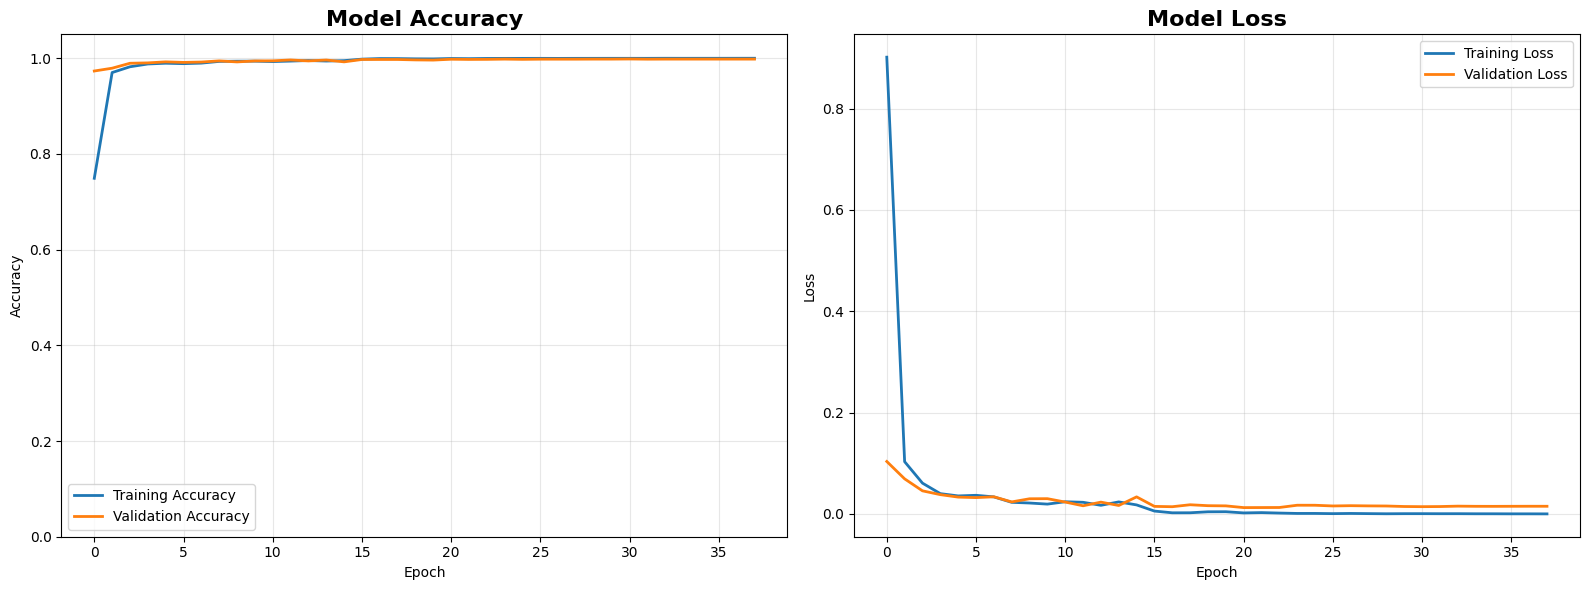

Plot disimpan ke: /kaggle/working/training_plot.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Loss
ax2.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=16, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke: /kaggle/working/training_plot.png")


## 9. Evaluasi Model pada Test Set

In [9]:
# Load model terbaik
model = keras.models.load_model('/kaggle/working/best_model.keras')

# Evaluasi pada setiap split
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)

print(f"Train Set      — Loss: {train_loss:.4f} | Accuracy: {train_acc*100:.2f}%")
print(f"Validation Set — Loss: {val_loss:.4f}   | Accuracy: {val_acc*100:.2f}%")
print(f"Test Set       — Loss: {test_loss:.4f}   | Accuracy: {test_acc*100:.2f}%")


Train Set      — Loss: 0.0000 | Accuracy: 100.00%
Validation Set — Loss: 0.0143   | Accuracy: 99.85%
Test Set       — Loss: 0.1801   | Accuracy: 97.78%


## 10. Classification Report & Confusion Matrix

                              precision    recall  f1-score   support

        Speed limit (20km/h)       0.98      1.00      0.99        60
        Speed limit (30km/h)       0.94      1.00      0.97       720
        Speed limit (50km/h)       0.97      1.00      0.98       750
        Speed limit (60km/h)       0.98      0.98      0.98       450
        Speed limit (70km/h)       0.99      0.99      0.99       660
        Speed limit (80km/h)       0.98      0.95      0.97       630
 End of speed limit (80km/h)       1.00      0.88      0.94       150
       Speed limit (100km/h)       1.00      0.99      0.99       450
       Speed limit (120km/h)       0.99      0.99      0.99       450
                  No passing       0.98      1.00      0.99       480
          No passing (>3.5t)       1.00      0.99      1.00       660
Right-of-way at intersection       0.96      0.98      0.97       420
               Priority road       1.00      0.96      0.98       690
                   

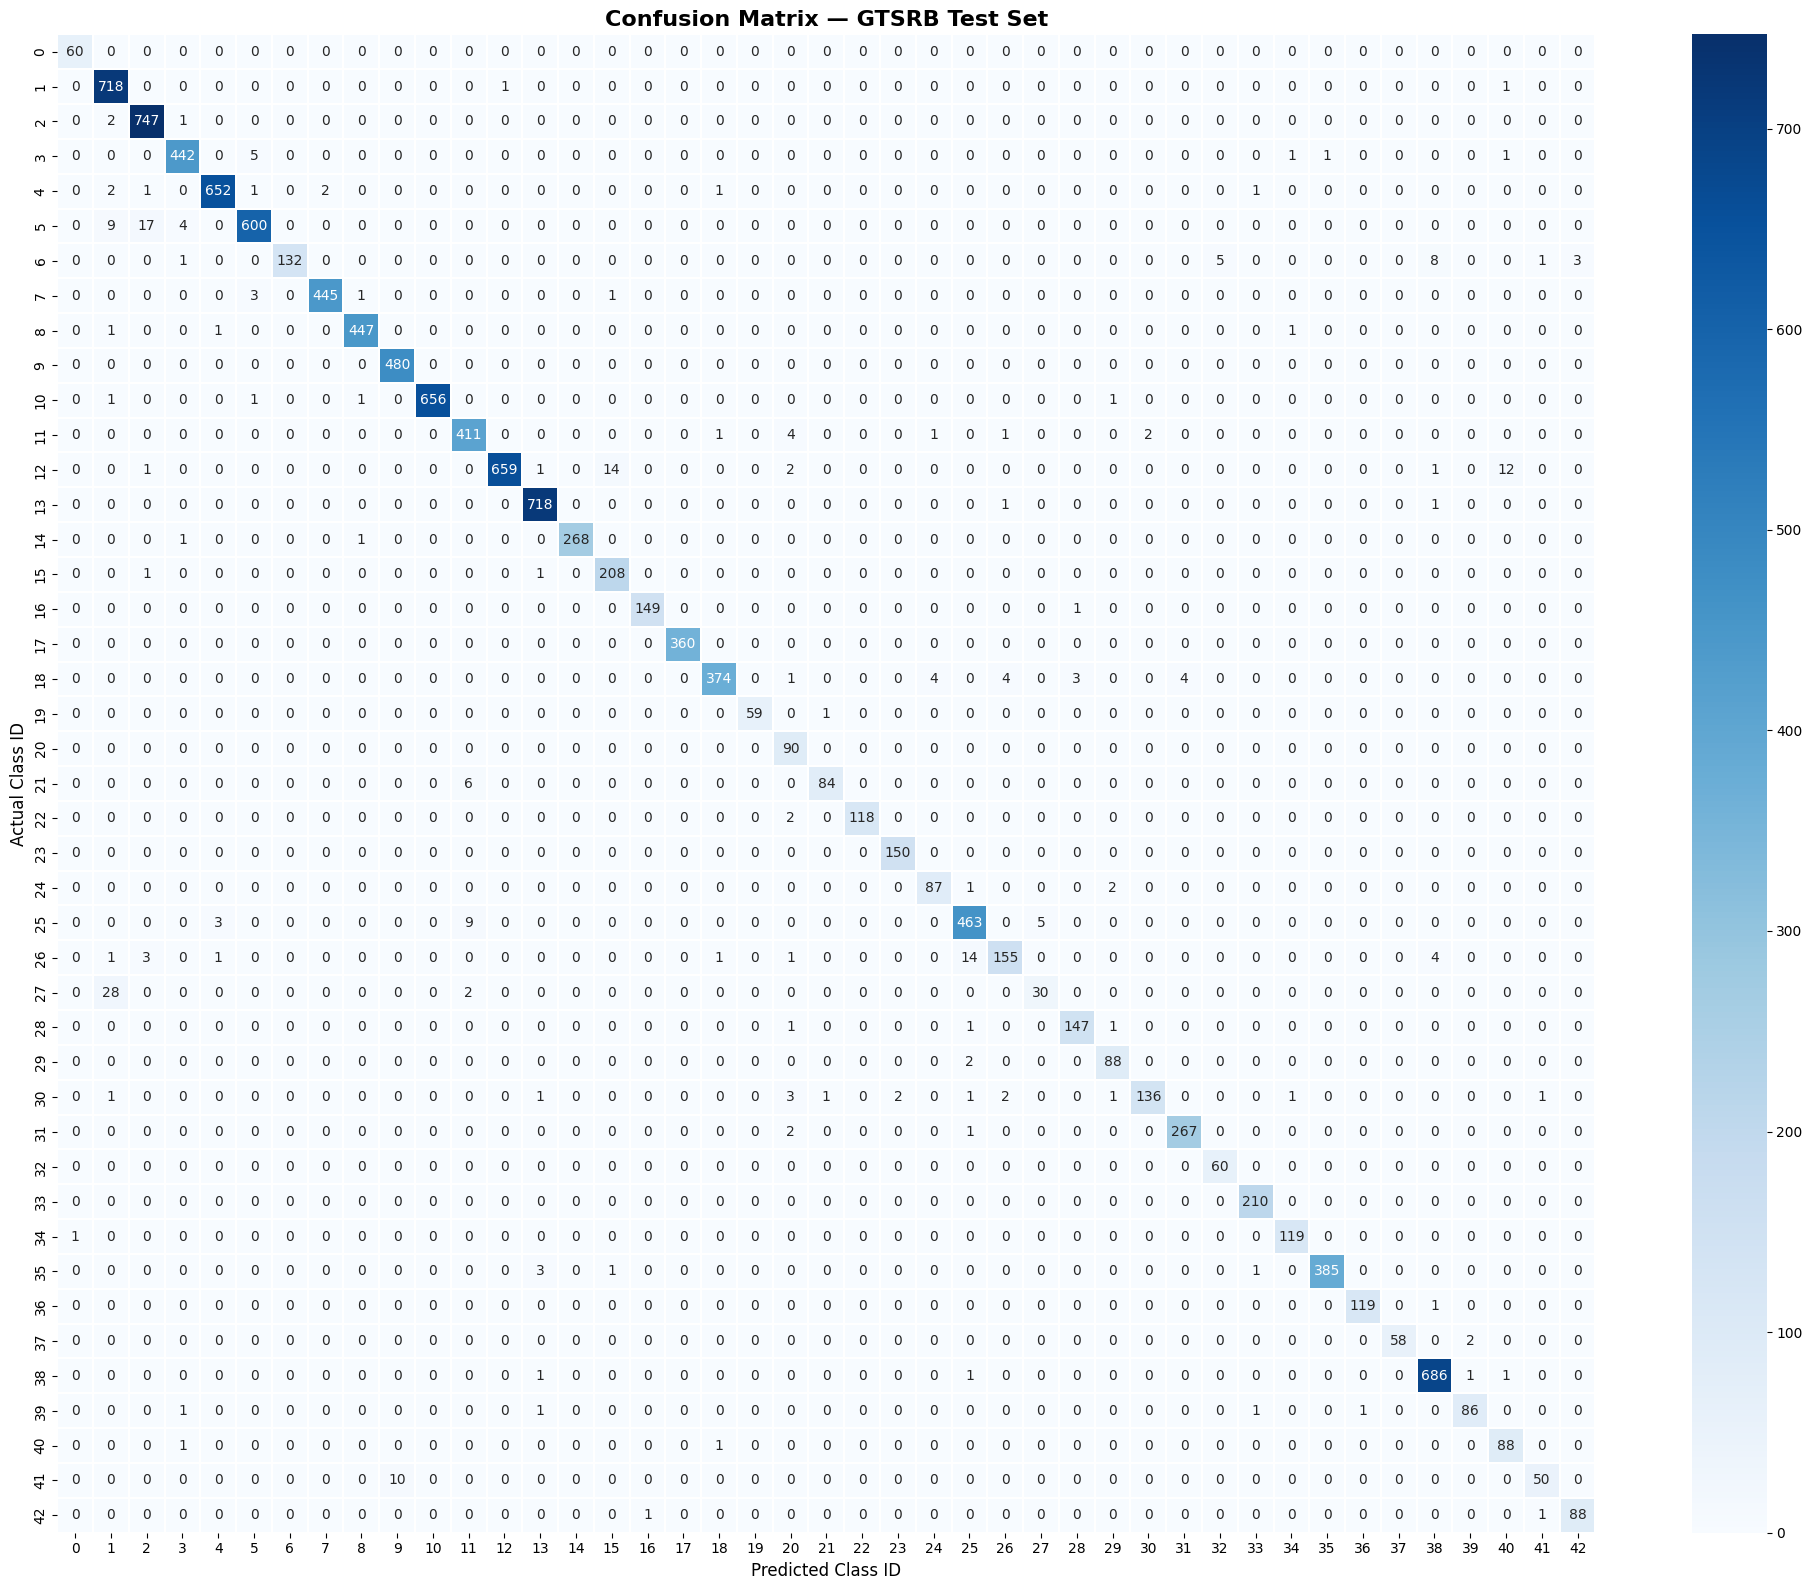

In [10]:
# Prediksi seluruh test set
y_pred_prob    = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = y_test_raw  

# Classification Report
short_names = [f'{i}: {n[:20]}' for i, n in enumerate(class_names)]
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.3,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.title('Confusion Matrix — GTSRB Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class ID', fontsize=12)
plt.ylabel('Actual Class ID',    fontsize=12)
plt.tight_layout()
plt.show()



## 11. Visualisasi Prediksi

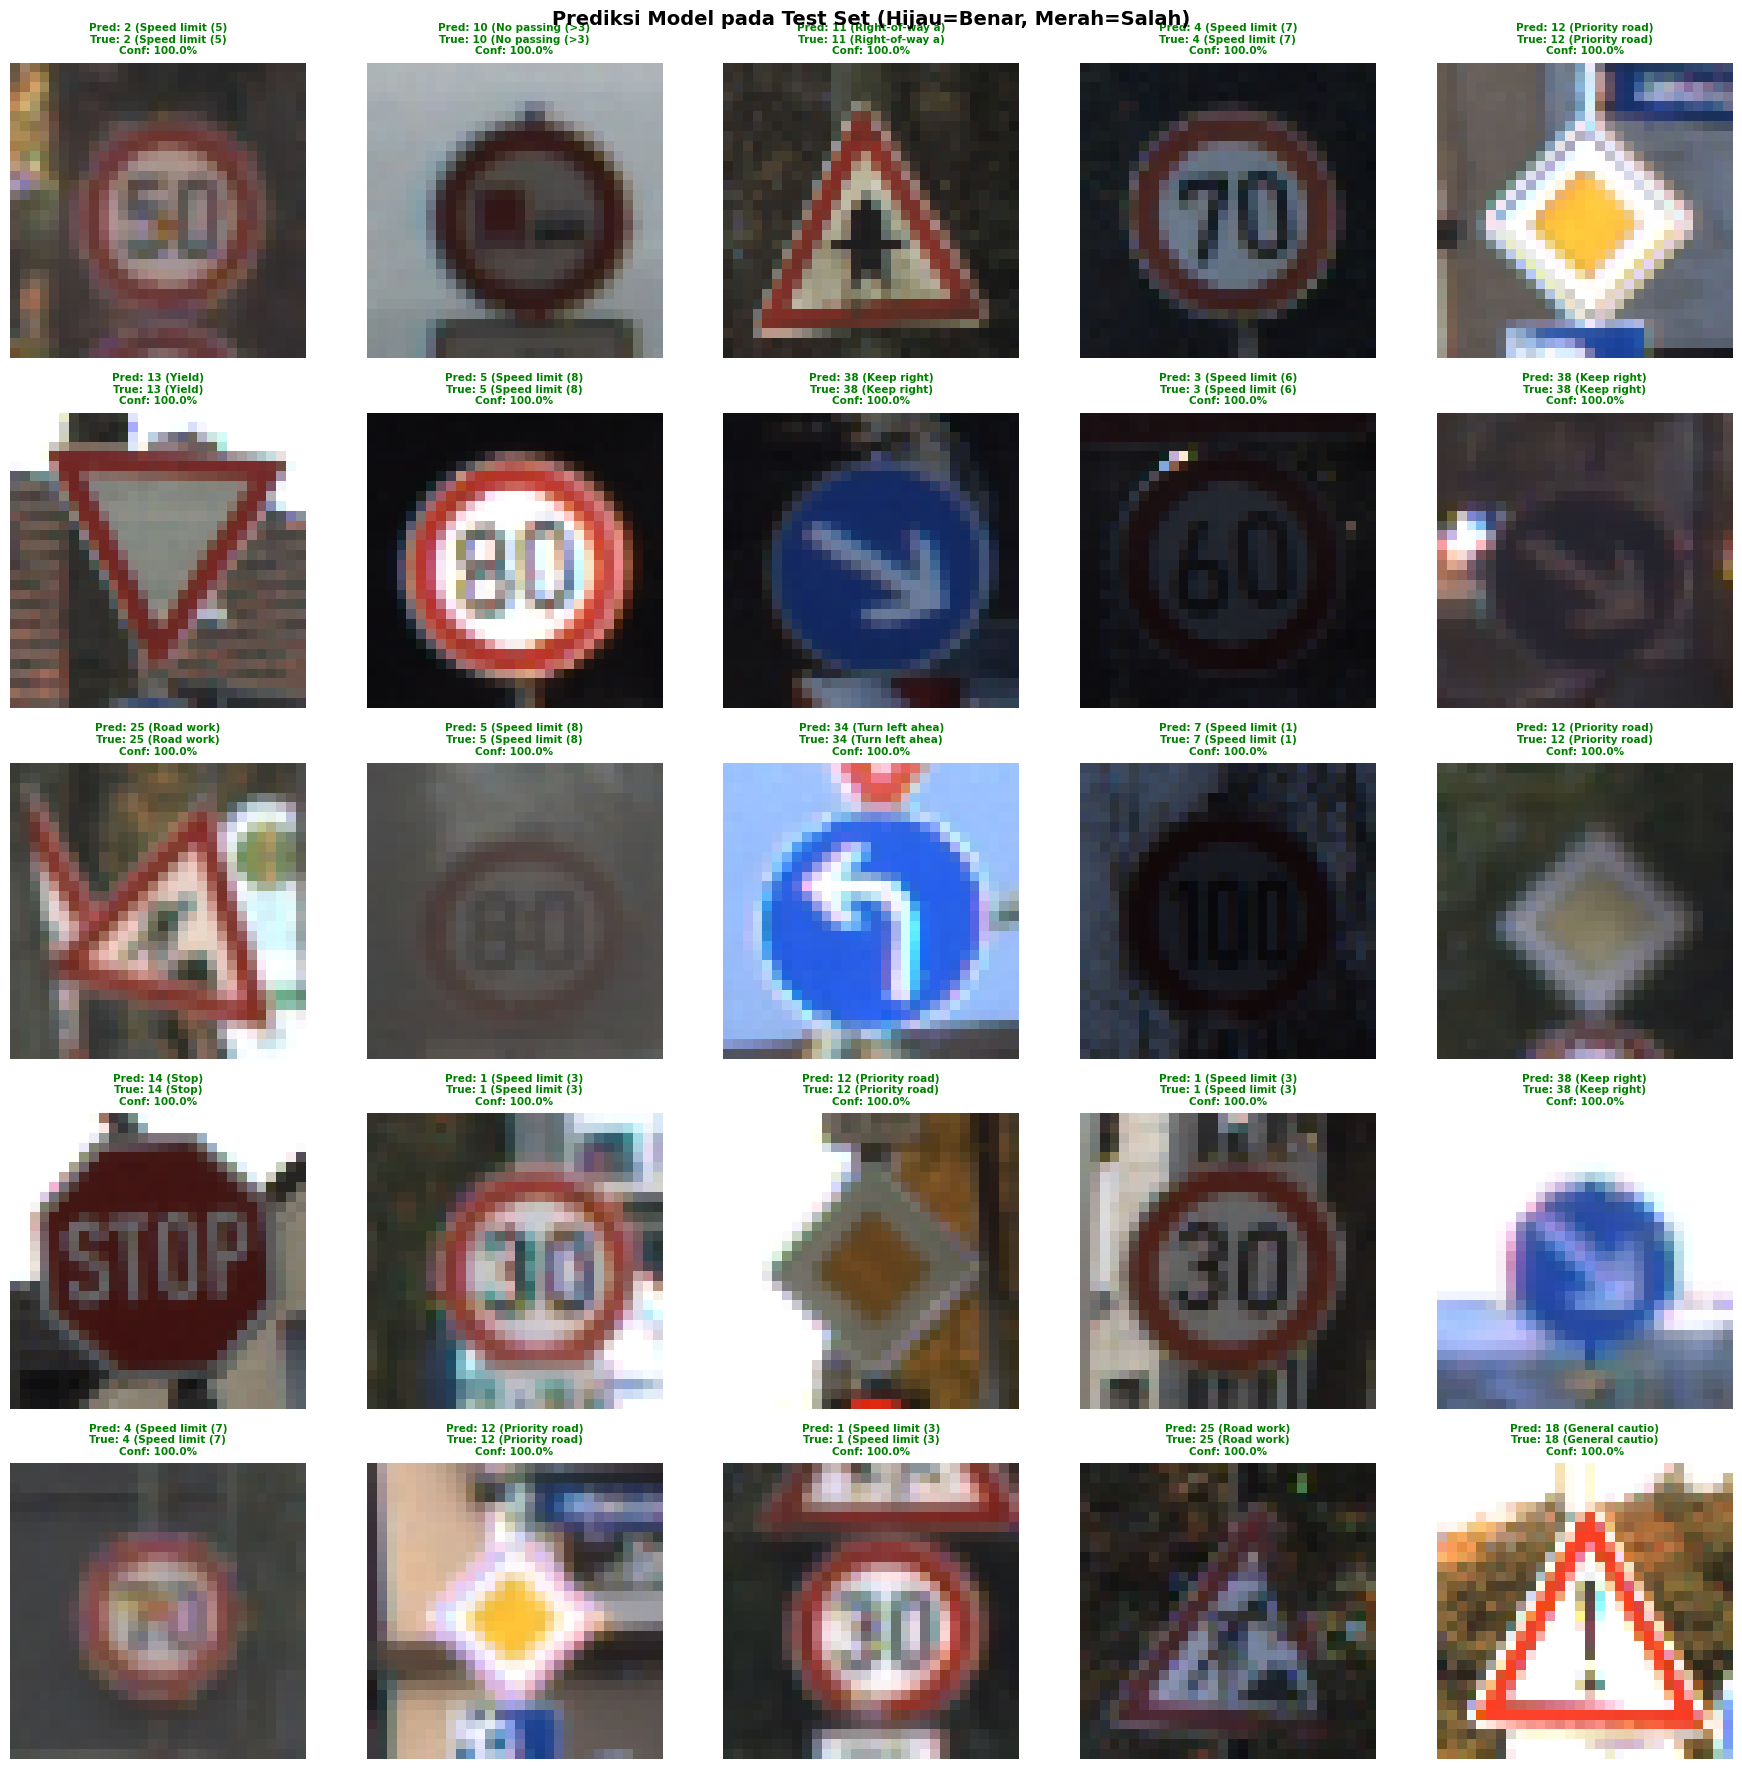

In [11]:
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(18, 18))
for i, idx in enumerate(sample_indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx])

    pred  = y_pred_classes[idx]
    true  = y_true_classes[idx]
    conf  = y_pred_prob[idx][pred] * 100
    color = 'green' if pred == true else 'red'

    ax.set_title(
        f'Pred: {pred} ({class_names[pred][:14]})\n'
        f'True: {true} ({class_names[true][:14]})\n'
        f'Conf: {conf:.1f}%',
        color=color, fontsize=7.5, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Prediksi Model pada Test Set (Hijau=Benar, Merah=Salah)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Simpan Model ke SavedModel, TF-Lite, dan TFJS

In [12]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.53.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==

In [ ]:
# SavedModel 
saved_model_dir = '/kaggle/working/saved_model'
model.export(saved_model_dir)
print(f"SavedModel disimpan ke: {saved_model_dir}/")

# TF-Lite 
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

os.makedirs('/kaggle/working/tflite', exist_ok=True)
tflite_path = '/kaggle/working/tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)


label_path = '/kaggle/working/tflite/label.txt'
with open(label_path, 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print(f"TF-Lite disimpan ke  : {tflite_path} ({os.path.getsize(tflite_path)/1024/1024:.2f} MB)")
print(f"Label disimpan ke    : {label_path}")

# TFJS 
tfjs_dir = '/kaggle/working/tfjs_model'
os.makedirs(tfjs_dir, exist_ok=True)

import subprocess
result = subprocess.run([
    'tensorflowjs_converter',
    '--input_format=tf_saved_model',
    '--output_format=tfjs_graph_model',
    saved_model_dir,
    tfjs_dir
], capture_output=True, text=True)

if result.returncode == 0:
    print(f"\nTFJS disimpan ke     : {tfjs_dir}/")
    for f in os.listdir(tfjs_dir):
        size = os.path.getsize(os.path.join(tfjs_dir, f)) / 1024
        print(f"  {f} ({size:.1f} KB)")
else:
    print("TFJS conversion error:", result.stderr)
    print("Pastikan tensorflowjs terinstall: !pip install tensorflowjs")


INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/saved_model/assets


Saved artifact at '/kaggle/working/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 30, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  134796874160016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874155024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874156560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874159632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874155792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874159248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874158288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874162704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874159056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134796874156368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13479

W0000 00:00:1771986506.391866      24 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771986506.391898      24 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1771986506.401128      24 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TF-Lite disimpan ke  : /kaggle/working/tflite/model.tflite (1.57 MB)
Label disimpan ke    : /kaggle/working/tflite/label.txt

TFJS disimpan ke     : /kaggle/working/tfjs_model/
  model.json (10.9 KB)
  group1-shard2of2.bin (2251.4 KB)
  group1-shard1of2.bin (4096.0 KB)


=== SavedModel Info ===
Input keys  : ['input_layer']
Output keys : ['output_0']

=== Hasil Inference SavedModel ===
No   True Label                     Predicted                      Confidence  Status
1    Road work                      Road work                         100.00%
2    Right-of-way at intersection   Right-of-way at intersection       96.78%
3    Keep right                     Keep right                        100.00%
4    Keep right                     Keep right                        100.00%
5    Speed limit (120km/h)          Speed limit (120km/h)             100.00%
6    Keep right                     Keep right                        100.00%
7    Speed limit (80km/h)           Speed limit (80km/h)              100.00%
8    Priority road                  Priority road                     100.00%
9    Road work                      Road work                         100.00%
10   Right-of-way at intersection   Right-of-way at intersection      100.00%

Akurasi inferenc

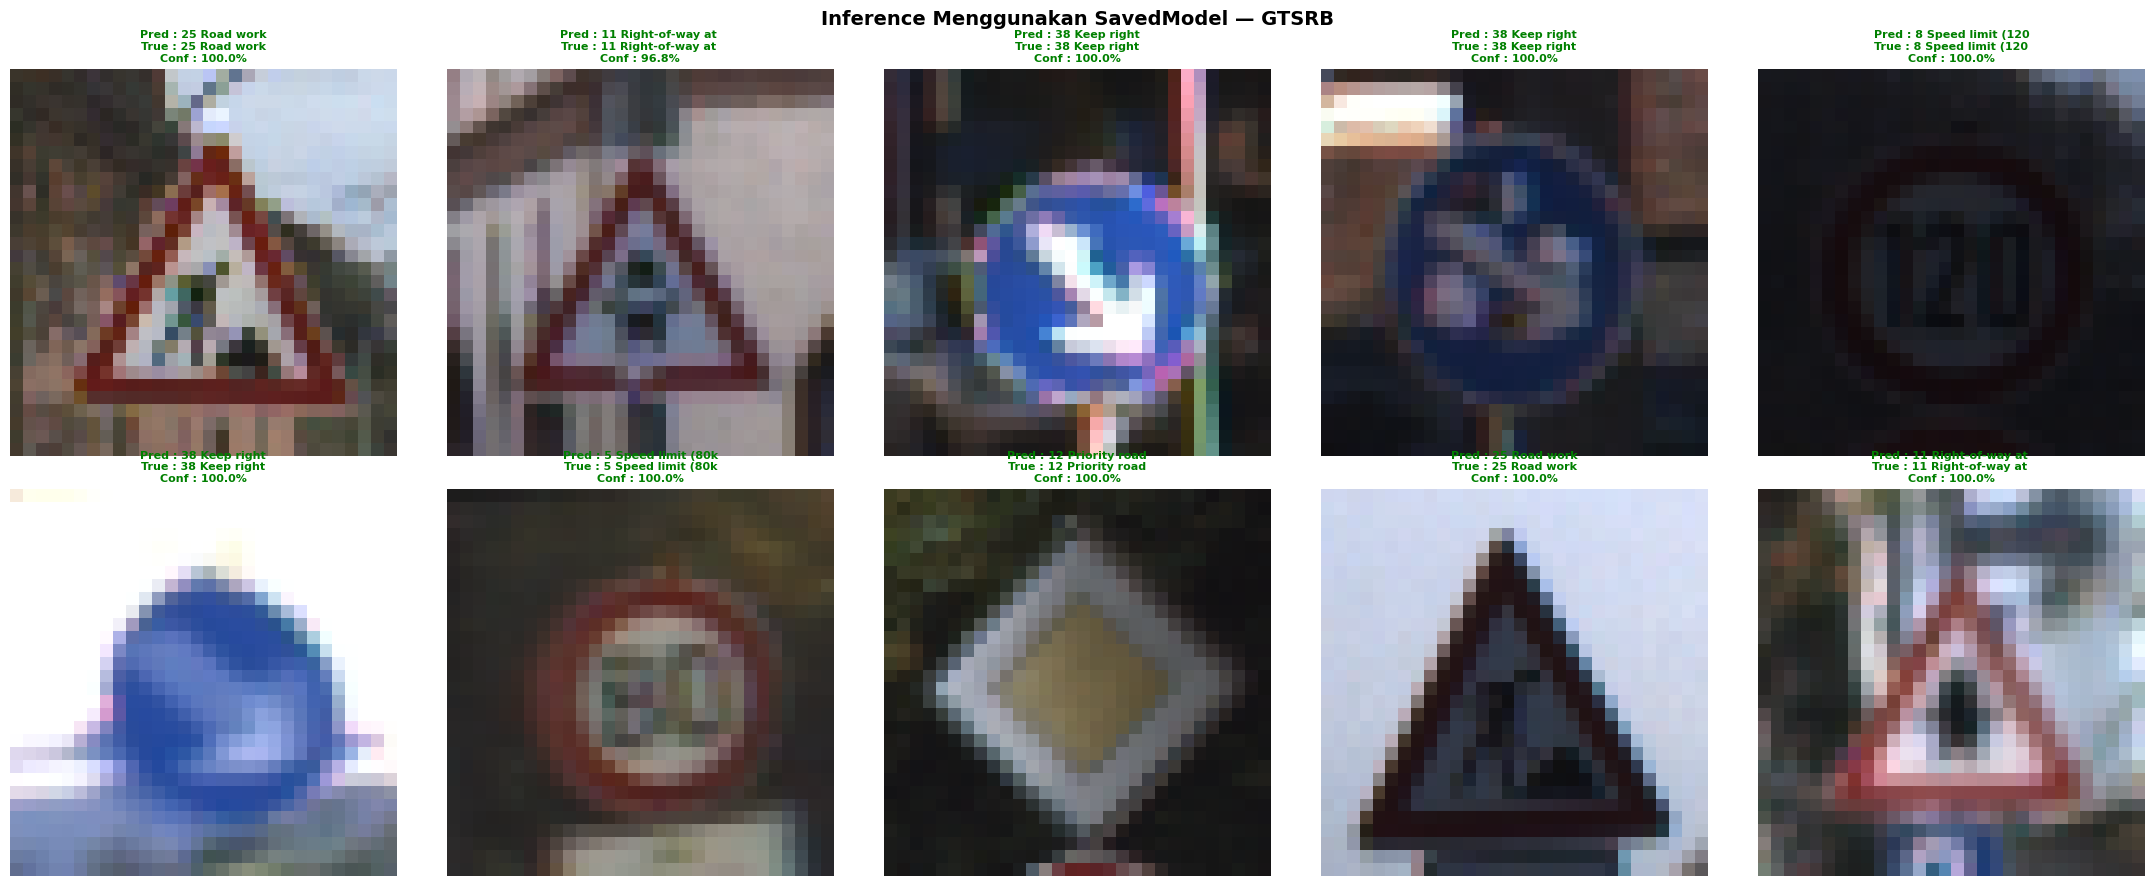

In [14]:
saved_model_dir = '/kaggle/working/saved_model'
saved_model = tf.saved_model.load(saved_model_dir)

infer = saved_model.signatures['serving_default']

print("=== SavedModel Info ===")
print(f"Input keys  : {list(infer.structured_input_signature[1].keys())}")
print(f"Output keys : {list(infer.structured_outputs.keys())}")

input_key  = list(infer.structured_input_signature[1].keys())[0]
output_key = list(infer.structured_outputs.keys())[0]

np.random.seed(0)
num_samples  = 10
test_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
correct = 0

print("\n=== Hasil Inference SavedModel ===")
print(f"{'No':<4} {'True Label':<30} {'Predicted':<30} {'Confidence':>10}  Status")


for i, idx in enumerate(test_indices):
    # Siapkan input tensor float32 (1, 30, 30, 3)
    input_tensor = tf.convert_to_tensor(
        np.expand_dims(X_test[idx], axis=0), dtype=tf.float32
    )

    # Inference
    output      = infer(**{input_key: input_tensor})
    probs       = output[output_key].numpy()[0]
    pred_class  = int(np.argmax(probs))
    confidence  = float(np.max(probs)) * 100
    true_class  = int(y_true_classes[idx])

    pred_label = class_names[pred_class]
    true_label = class_names[true_class]
    if pred_class == true_class:
        correct += 1

    print(f"{i+1:<4} {true_label:<30} {pred_label:<30} {confidence:>9.2f}%")

    # Visualisasi
    ax    = axes[i // 5, i % 5]
    color = 'green' if pred_class == true_class else 'red'
    ax.imshow(X_test[idx])
    ax.set_title(
        f'Pred : {pred_class} {pred_label[:16]}\n'
        f'True : {true_class} {true_label[:16]}\n'
        f'Conf : {confidence:.1f}%',
        color=color, fontsize=8, fontweight='bold'
    )
    ax.axis('off')

print(f"\nAkurasi inference SavedModel : {correct}/{num_samples} ({correct/num_samples*100:.0f}%)")

plt.suptitle('Inference Menggunakan SavedModel — GTSRB',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
